#### SALES & REVENUE PERFORMANCE (Business Core)<br> Business Objective: Understand how money is generated  

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_parquet("../data/03_merged/ecommerce_merged.parquet")

In [79]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,...,500.0,19.0,8.0,13.0,9350,maua,SP,3149.0,-23.576983,-46.587161
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,...,500.0,19.0,8.0,13.0,9350,maua,SP,3149.0,-23.576983,-46.587161
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,...,500.0,19.0,8.0,13.0,9350,maua,SP,3149.0,-23.576983,-46.587161
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,...,400.0,19.0,13.0,19.0,31570,belo horizonte,SP,47813.0,-12.177924,-44.660711
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,...,420.0,24.0,19.0,21.0,14840,guariba,SP,75265.0,-16.745150,-48.514783


##### Which product categories generate the highest revenue?

In [80]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'no_review_message',
       'review_message', 'review_creation_date', 'review_answer_timestamp',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_ename', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng'],
      dtype='object')

In [81]:
df.loc[0:5,['order_id','order_item_id', 'product_id', 'price']]

,order_id,order_item_id,product_id,price
0,e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,29.99
3,53cdb2fc8bc7dce0b6741e2150273451,1,595fac2a385ac33a80bd5114aec74eb8,118.70
4,47770eb9100c2d0c44946d9cf07ec65d,1,aa4383b373c6aca5d8797843e5594415,159.90
5,949d5b44dbf5de918fe9c16f97b45f8a,1,d0b61bfb1de832b15ba9d266ca96e5b0,45.00


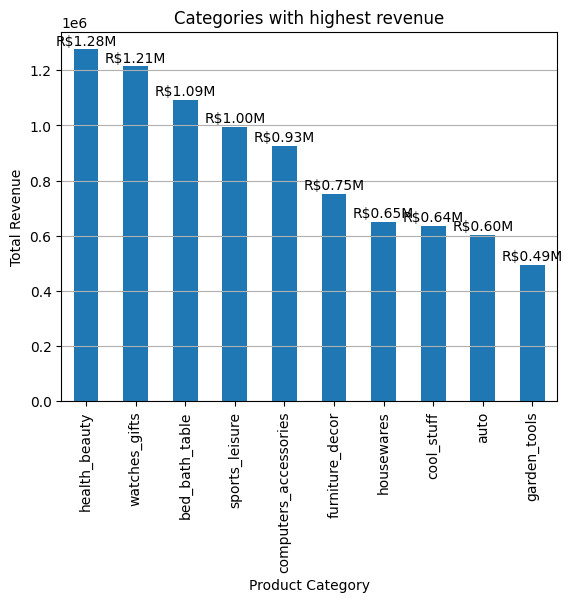

<Figure size 1200x2000 with 0 Axes>

In [110]:
ax=df.groupby('product_category_ename')['price'].sum().sort_values(ascending=False).reset_index().head(10).plot(kind='bar', x='product_category_ename', y='price', legend=False)
for bars in ax.containers:
    ax.bar_label(bars, labels=[f"R${v/1e6:.2f}M" for v in bars.datavalues], padding=1)
  
plt.title("Categories with highest revenue")
plt.ylabel("Total Revenue")
plt.xlabel("Product Category")
plt.grid(True, axis = 'y')
plt.figure(figsize=(12,20))
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/01_Categories with highest revenue.png')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### Health & Beauty, Watches & Gifts, and Bed Bath & Table are the highest revenue-generating categories, each contributing over 1 million in sales. These categories are critical revenue drivers and should be prioritized for marketing efforts, inventory planning, and faster delivery strategies to maximize business impact.

##### Which cities/states contribute most to sales?

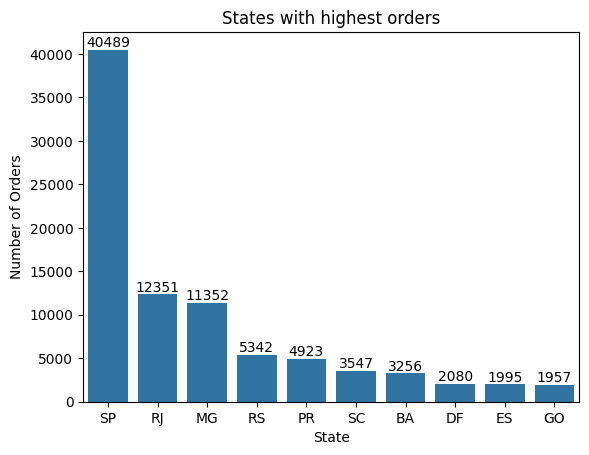

In [83]:
ax = df.groupby('customer_state')['order_id'].nunique().nlargest(10).reset_index() # for counting each individual unique orders by state
ax=sns.barplot(data= ax, x="customer_state", y="order_id")
for bars in ax.containers:
   ax.bar_label(bars)
plt.xlabel("State")
plt.ylabel("Number of Orders")
plt.title("States with highest orders")
# This line automates the saving
plt.savefig(f'../visuals/02_States with highest orders.png')
plt.show()
 
plt.close() # Important: closes the plot so it doesn't eat up memory

###### Orders are highly concentrated in São Paulo (SP) relative to other states, indicating uneven geographic demand. The business can prioritize SP for premium delivery services while designing growth strategies to expand adoption in underperforming regions.

##### What is the monthly sales trend? (growth or decline?)

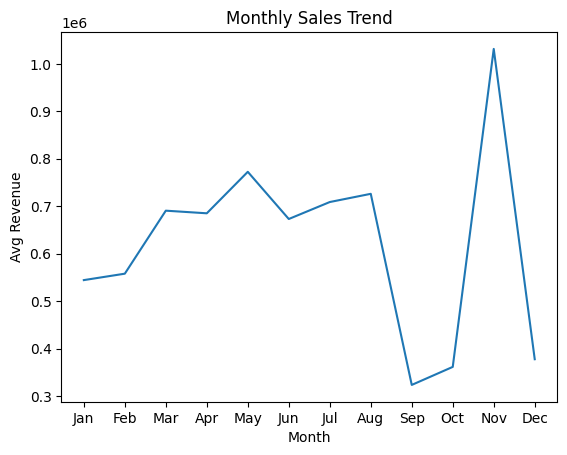

In [84]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
sales_sum=df.groupby('order_month')['price'].sum().reset_index().sort_values(by='order_month')
sales_sum['month_only'] = sales_sum['order_month'].dt.month
sales_avg= sales_sum.groupby('month_only')['price'].mean().reset_index().sort_values(by='month_only')
ax = sns.lineplot(data=sales_avg, x='month_only', y='price')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Avg Revenue")
plt.xticks(ticks=np.arange(1,13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
# This line automates the saving
plt.savefig(f'../visuals/03_Monthly Sales Trend.png')
plt.show()
   
plt.close() # Important: closes the plot so it doesn't eat up memory


###### November shows the highest average monthly revenue, while September has the lowest, indicating a strong seasonal pattern in customer demand. This suggests that marketing and inventory planning should focus on November to maximize revenue, while promotional strategies in September could help boost sales during low-demand periods.

##### What is the Average Order Value (AOV) by category?

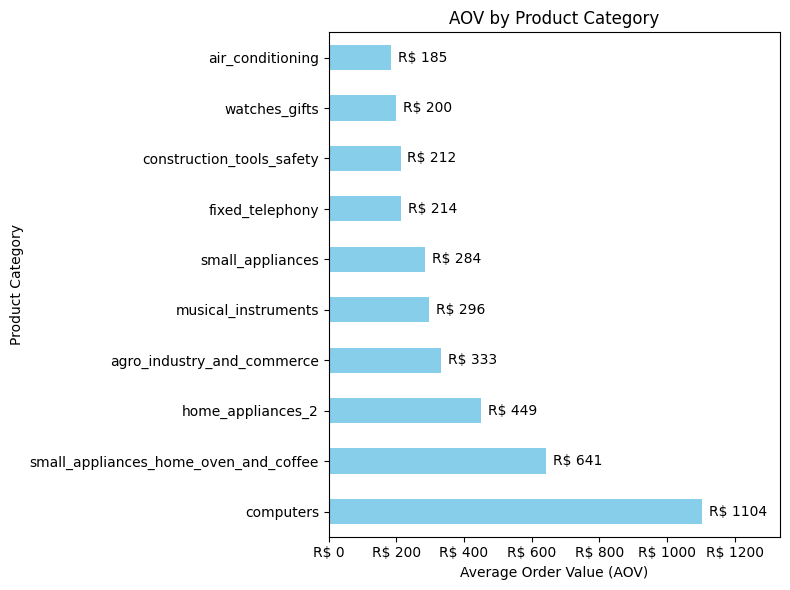

In [85]:
import matplotlib.ticker as ticker
ax=df.groupby('product_category_ename').price.mean().nlargest(10).plot(kind='barh', figsize=(8,6), color='skyblue')

#  Add labels to the end of the bars
# fmt='R$ %.2f' adds the prefix and formats to 2 decimal places
for container in ax.containers:
    ax.bar_label(container, fmt='R$ %.0f', padding=5)

#  Format the X-axis tick labels as well
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('R$ %.0f'))

plt.title("AOV by Product Category")
plt.xlabel("Average Order Value (AOV)")
plt.ylabel("Product Category")
# Adjust limits so labels don't get cut off
plt.xlim(0, ax.get_xlim()[1] * 1.15) 
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/04_AOV by Product Category.png')
plt.show()
 
plt.close() # Important: closes the plot so it doesn't eat up memory


###### The Computers category shows the highest AOV, making it the most valuable segment per transaction. Focusing marketing and premium service offerings on high-AOV categories could significantly increase overall revenue, while bundle strategies may help improve AOV in lower-value categories.

##### Which sellers contribute most to revenue?

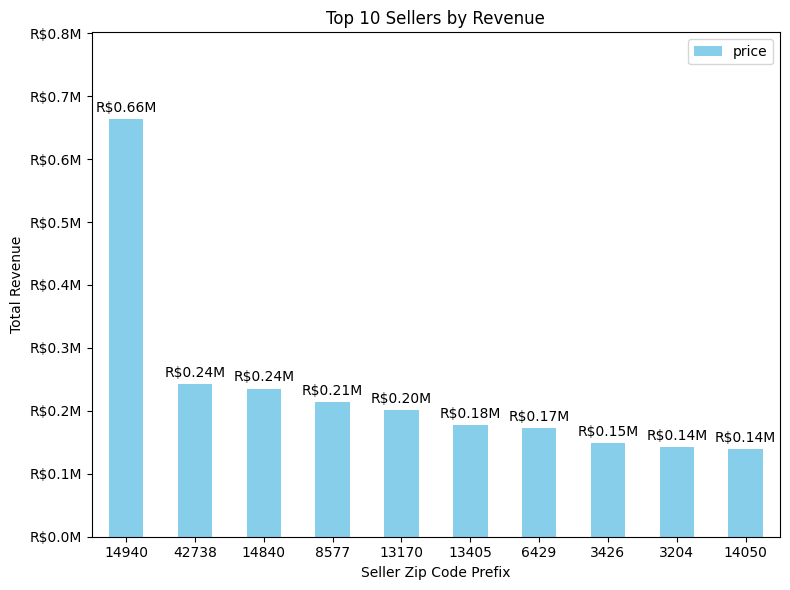

In [86]:
# groupby
ax=df.groupby('seller_zip_code_prefix')['price'].sum().nlargest(10).reset_index().plot(kind='bar', x='seller_zip_code_prefix', y='price', color="skyblue",figsize=(8,6))
# add labels
for bars in ax.containers:
    ax.bar_label(bars, labels=[f"R${v/1e6:.2f}M" for v in bars.datavalues], padding=3)

#  Format the Y-axis tick labels as well
# use a FuncFormatter to divide the raw value by 1,000,000

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"R${x/1e6:.1f}M"))

plt.title("Top 10 Sellers by Revenue")
plt.ylabel("Total Revenue")
plt.xlabel("Seller Zip Code Prefix")
plt.xticks(rotation=0)
# Adjust limits so labels don't get cut off
plt.ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/05_Top 10 Sellers by Revenue.png')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### A small number of sellers contribute a disproportionate share of total revenue, highlighting seller concentration. Strengthening partnerships with top sellers and developing mid-tier sellers can help stabilize and grow overall revenue.

In [87]:
# view for columns
cols = pd.DataFrame(df.columns, columns=['column'])
display(cols)

,column
0,order_id
1,customer_id
2,order_status
3,order_purchase_timestamp
4,order_approved_at
5,order_delivered_carrier_date
6,order_delivered_customer_date
7,order_estimated_delivery_date
8,payment_sequential
9,payment_type


##### Do high freight costs reduce purchase value?

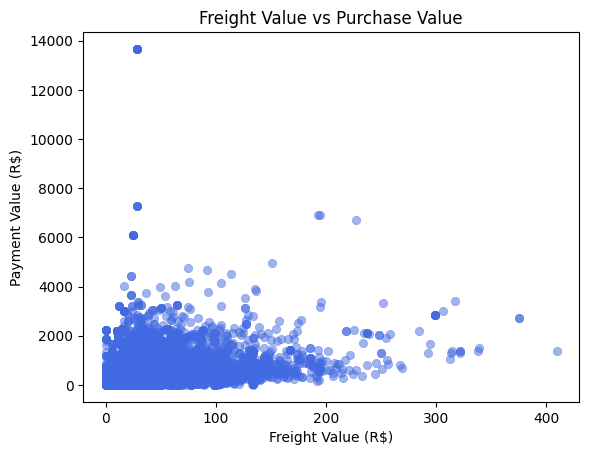

In [88]:
sns.scatterplot(data=df, x='freight_value', y='payment_value',color='royalblue',   # A clean, professional blue
    alpha=0.5,           # Makes overlapping points visible
    edgecolor=None       # Removes the white outline for a smoother look
    )
plt.title("Freight Value vs Purchase Value")
plt.xlabel("Freight Value (R$)")
plt.ylabel("Payment Value (R$)")
# This line automates the saving
plt.savefig(f'../visuals/06_Freight Value vs Purchase Value.png')
plt.show()
 
plt.close() # Important: closes the plot so it doesn't eat up memory

###### Freight value does not increase proportionally with purchase value, implying that shipping costs are not aligned with order size. Reducing freight charges or offering free shipping thresholds could help increase average order value.

##### DELIVERY & LOGISTICS PERFORMANCE (Operations Focus) <br> Business Objective: Reduce delays & improve efficiency.

##### What is the average delivery time?  

In [89]:
df['delivery_days']=df['order_delivered_customer_date'] - df['order_approved_at']
df['delivery_days']=df['delivery_days'].dt.days
df['delivery_days']

0          8
1          8
2          8
3         12
4          9
          ..
115701    22
115702    24
115703    17
115704    17
115705     7
Name: delivery_days, Length: 115706, dtype: int64

###### avg. delivery time 12 days

##### Which cities have the longest delivery delays?

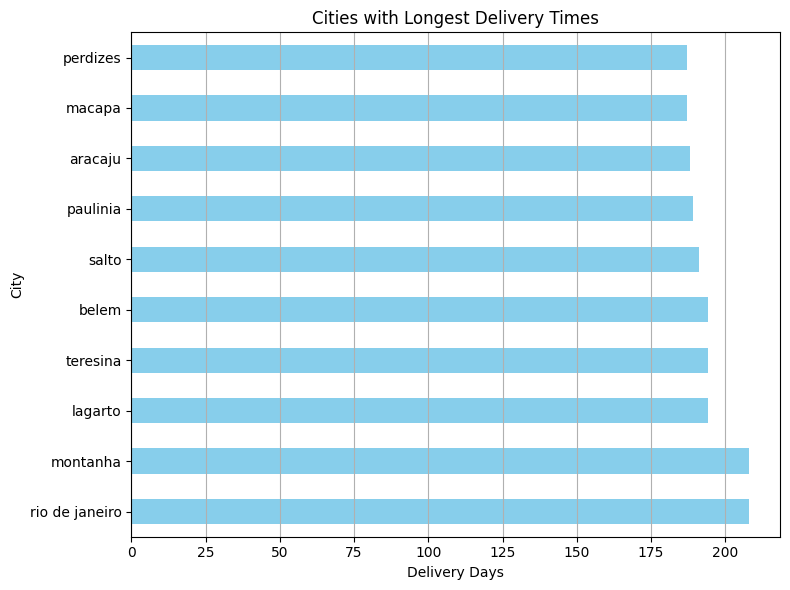

In [90]:
df.groupby('customer_city')['delivery_days'].max().sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,6), color='skyblue')
plt.title("Cities with Longest Delivery Times")
plt.xlabel("Delivery Days")
plt.ylabel("City")
plt.grid(True, axis='x')
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/07_Cities with Longest Delivery Times.png')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

##### How many orders are delivered late vs on time?

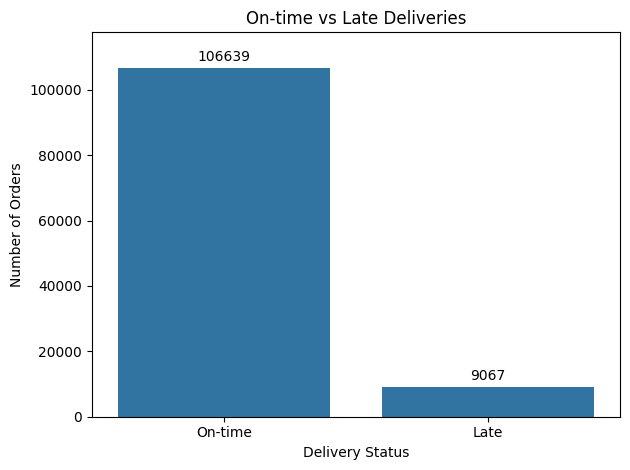

In [91]:
df['is_late'] = np.where(df['order_delivered_customer_date'] > df['order_estimated_delivery_date'],True,False)
ax=sns.countplot(data=df, x='is_late') 
for bars in ax.containers:
   ax.bar_label(bars, padding=3)
plt.ylim(0, ax.get_ylim()[1] * 1.05)
plt.title("On-time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(ticks=np.arange(0,2),labels=['On-time', 'Late'])
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/08_On-time vs Late Deliveries.png')
plt.show()
    
plt.close() # Important: closes the plot so it doesn't eat up memory

###### Although most orders are delivered on time, a notable number of late deliveries remain. Analyzing the drivers of these delays can help improve logistics performance and reduce future delivery issues.


##### Do late deliveries lead to lower customer ratings?

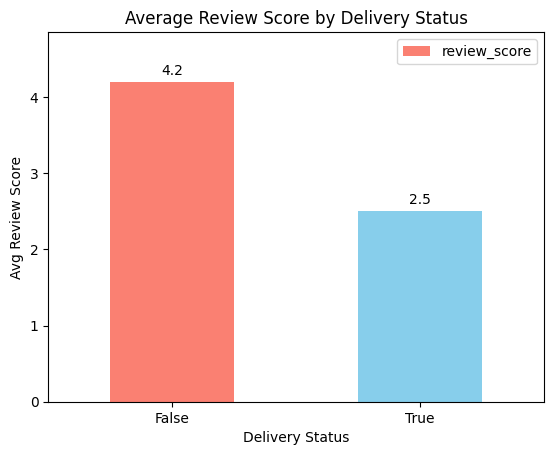

In [92]:
ax=df.groupby('is_late')['review_score'].mean().round(1).reset_index().plot(kind='bar', x='is_late', y='review_score', color=['salmon','skyblue' ])
for bars in ax.containers:
   ax.bar_label(bars, padding=3)
plt.ylim(0, ax.get_ylim()[1] * 1.10)
plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Avg Review Score")
plt.xticks(rotation=0)
# This line automates the saving
plt.savefig(f'../visuals/09_Average Review Score by Delivery Status.png')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### Orders delivered late receive significantly lower ratings than on-time orders, highlighting delivery speed as a critical factor in customer satisfaction. Improving delivery reliability can directly enhance customer experience and support business growth.

##### Which sellers cause the most delays?

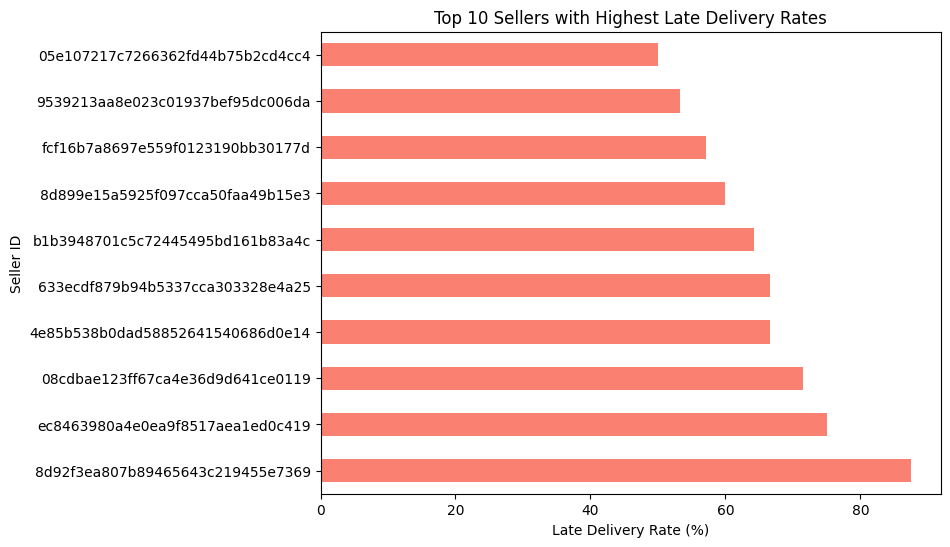

In [93]:
# Mean of a boolean column gives the percentage (0.1 = 10%)
late_rate = df.groupby('seller_id')['is_late'].mean() * 100

# Get the top 10 sellers with the worst late rates (minimum 5 orders to avoid outliers)
seller_counts = df.groupby('seller_id').size()
worst_offenders = late_rate[seller_counts > 5].nlargest(10)
worst_offenders.plot(kind='barh', color='salmon', figsize=(8,6))
plt.title("Top 10 Sellers with Highest Late Delivery Rates")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")
# This line automates the saving
plt.savefig(f'../visuals/10_Top 10 Sellers with Highest Late Delivery Rates.png')
    
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### A few sellers account for most late deliveries, with rates above 50–80%, threatening customer satisfaction and brand trust. Enforcing stricter seller performance standards or controlled fulfillment can quickly improve delivery reliability.

##### Is delivery time improving or worsening over time?

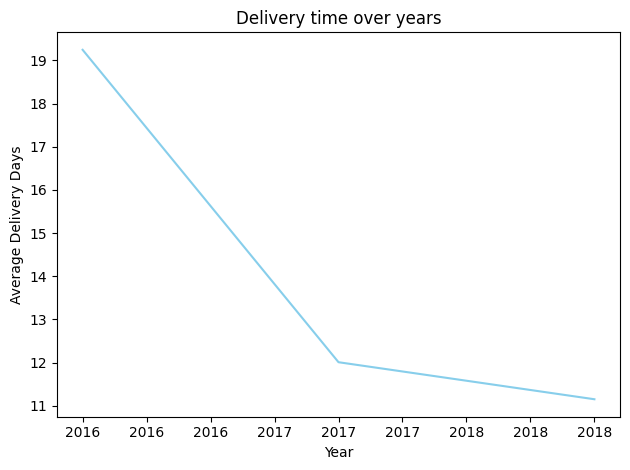

In [94]:
ax=df.groupby(df['order_month'].dt.year)['delivery_days'].mean().plot(kind='line', color='skyblue')
#  Format the X-axis tick labels 
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
plt.title("Delivery time over years")
plt.xlabel("Year")
plt.ylabel("Average Delivery Days")
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/11_Delivery time over years.png')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### Delivery reliability is a major driver of customer loyalty and repeat purchases, while late deliveries silently damage brand trust and increase churn. Sellers with high late rates create operational costs and reputational risk, making performance enforcement essential. Focusing on accurate delivery promises and last-mile optimization can improve customer satisfaction and profitability simultaneously.

##### CUSTOMER BEHAVIOR & LOYALTY (Marketing View) <br> Business Objective: Retain customers & increase repeat purchases

##### What percentage of customers are repeat buyers?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8592\3684264162.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis', ax=ax[1])


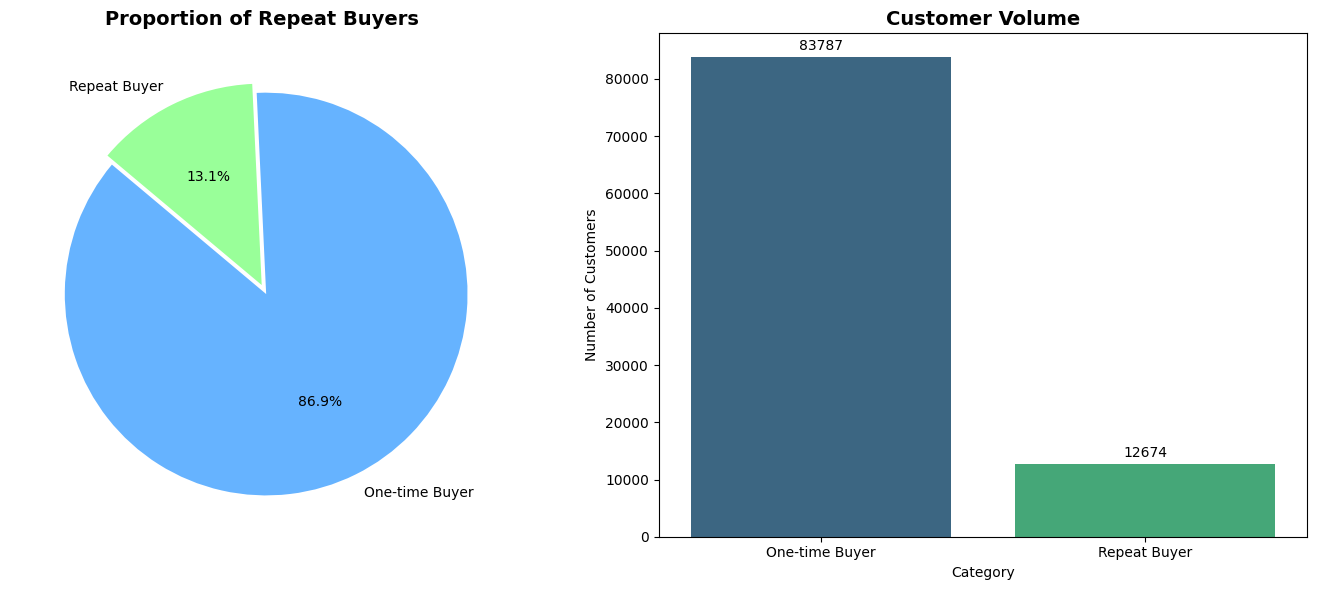

In [95]:
mask = df['customer_id'].value_counts() > 1
# We map False to 'One-time' and True to 'Repeat' for better labels
plot_data = mask.value_counts().rename({True: 'Repeat Buyer', False: 'One-time Buyer'})

#  Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# --- Left Plot: Pie Chart ---
ax[0].pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', 
          colors=['#66b3ff','#99ff99'], startangle=140, explode=(0.05, 0))
ax[0].set_title('Proportion of Repeat Buyers', fontsize=14, fontweight='bold')

# --- Right Plot: Bar Chart ---
# Map the barplot to the second subplot (right side)
sns.barplot(x=plot_data.index, y=plot_data.values, palette='viridis', ax=ax[1])
ax[1].set_title('Customer Volume', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Number of Customers')
ax[1].set_xlabel('Category')

# labels on bars
for bars in ax[1].containers:
    ax[1].bar_label(bars, padding=3)

plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/12_Customer Volume.png')
    
plt.show()   

plt.close() # Important: closes the plot so it doesn't eat up memory

###### Only 13.1% of customers are repeat buyers, showing a major retention gap despite strong customer acquisition. Growth is constrained more by customer experience than by reach. Improving delivery performance, particularly from high-delay sellers, is a key lever to convert one-time buyers into loyal customers.

##### Which states have the highest repeat customer rate?

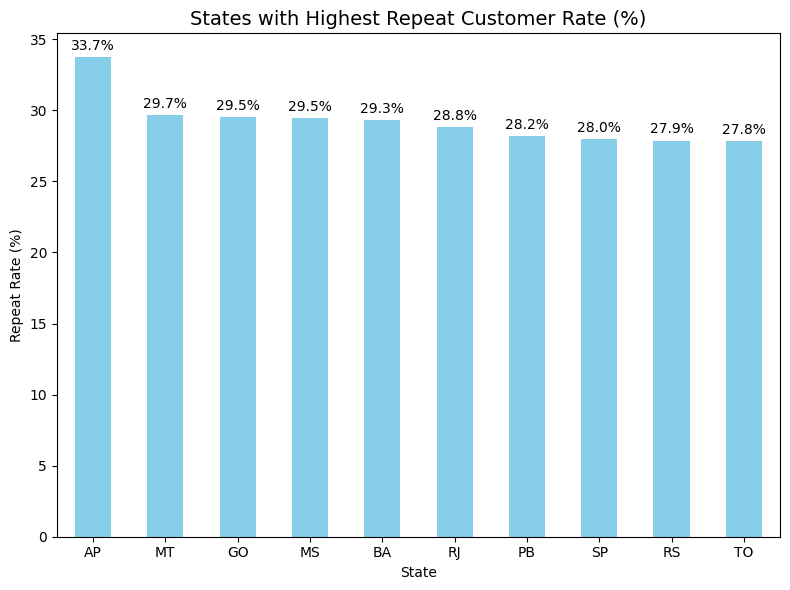

In [96]:
fig, ax = plt.subplots(figsize=(8,6))
#  Map the repeat status back to your main DataFrame
# 'mask' is the True/False Series indexed by customer_id
df['is_repeat']=df['customer_id'].map(mask).fillna(False)

# 2. Group by state and calculate the mean of 'is_repeat'
# Since True=1 and False=0, the mean is the exact percentage
state_repeat_rate = df.groupby('customer_state')['is_repeat'].mean()*100

# plot the data
ax= state_repeat_rate.nlargest(10).plot(kind='bar', color='skyblue')
# labels for bars
for bars in ax.containers:
    ax.bar_label(bars, fmt ='%.1f%%', padding=3)

# titles and labels
plt.title("States with Highest Repeat Customer Rate (%)", fontsize=14)
plt.ylabel("Repeat Rate (%)")
plt.xlabel("State")
plt.xticks(rotation=0)
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/13_States with Highest Repeat Customer Rate (%).png')
    
plt.show()
plt.close() # Important: closes the plot so it doesn't eat up memory


###### Repeat purchase behavior varies significantly by state, with AP showing the highest repeat customer rate (~34%), while larger markets like SP and RS show relatively lower loyalty (~28%). This indicates that customer retention is stronger in smaller or niche regions but weaker in high-volume states.Targeted loyalty programs and improved delivery experience in major states like SP could unlock substantial growth in repeat purchases.

##### Do repeat customers spend more than new customers?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8592\1689549942.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=order_df, x='is_repeat', y='price', palette=['salmon', 'skyblue'])


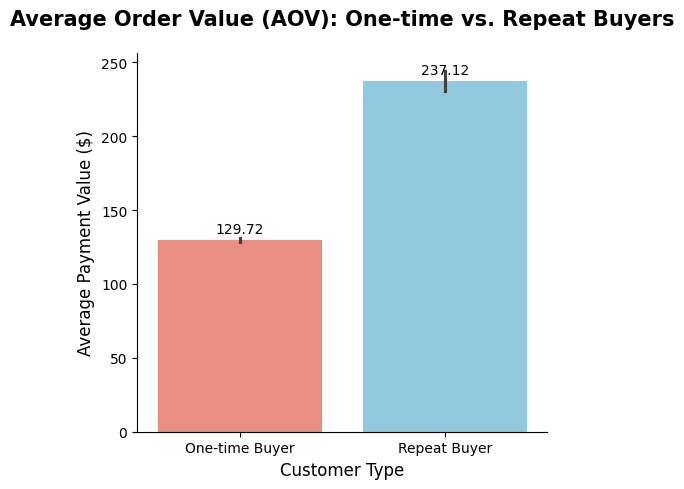

In [97]:
# 1. Calculate the AOV for the report
order_revenue = df.groupby('order_id')['price'].sum().reset_index()
order_repeat = df[['order_id', 'is_repeat']].drop_duplicates()
order_df = order_revenue.merge(order_repeat, on = 'order_id')

# 2. Create the plot
plt.figure(figsize=(5, 5))
ax = sns.barplot(data=order_df, x='is_repeat', y='price', palette=['salmon', 'skyblue'])

# 3. Add value labels on top of bars
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fmt='%.2f')

# 4. Add Title and Axis Labels
plt.title('Average Order Value (AOV): One-time vs. Repeat Buyers', fontsize=15, pad=20 ,fontweight='bold')
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Average Payment Value ($)', fontsize=12)

# 5. Change x-ticks from [False, True] to [One-time, Repeat]
plt.xticks(ticks=[0, 1], labels=['One-time Buyer', 'Repeat Buyer'])

# 6. Final styling cleanup
sns.despine() # Removes top and right borders for a cleaner look
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/14_Average Order Value (AOV)- One-time vs Repeat Buyers')
plt.show()
 
plt.close() # Important: closes the plot so it doesn't eat up memory


###### While logistics improved drastically from 19 to 11 days by 2018, the platform faces a "leaky bucket" problem where 86.9% of customers are one-time buyers. Repeat buyers are high-value assets who spend nearly double ($237 vs $129) per order, yet their loyalty is threatened by a group of outlier sellers with late delivery rates exceeding 50–80%. Strategic growth depends on converting one-time buyers into loyalists by enforcing stricter delivery standards on these "worst offender" sellers to protect high-value regional repeat rates.

##### What is the order frequency per customer?

In [98]:
print(df.groupby('customer_unique_id')['order_id'].nunique().mean().round(0))

1.0


###### The average order frequency is close to 1, indicating that most customers make only a single purchase. This highlights a major retention gap, where customer acquisition is strong but repeat purchasing is limited. Improving post-purchase experience, especially delivery reliability and seller performance, is critical to increasing customer lifetime value.

##### Are repeat customers more tolerant of delivery delays?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8592\184856802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ax, x='is_repeat', y='review_score',palette=['salmon','skyblue'])


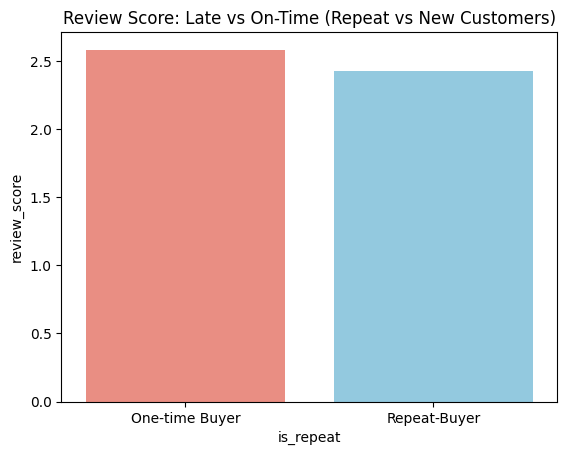

In [99]:
review_repeat=df.groupby(['is_late','is_repeat'])['review_score'].mean().reset_index()
ax = review_repeat[review_repeat['is_late'] == True][['is_repeat','review_score']].reset_index()
sns.barplot(data=ax, x='is_repeat', y='review_score',palette=['salmon','skyblue'])
plt.title("Review Score: Late vs On-Time (Repeat vs New Customers)")
plt.xticks(ticks=[0,1], labels=['One-time Buyer', 'Repeat-Buyer'])
# This line automates the saving
plt.savefig(f'../visuals/15_Review Score- Late vs On-Time (Repeat vs New Customers)')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### Repeat customers give lower review scores for late deliveries compared to on-time deliveries, indicating that loyal customers are not more tolerant of delays. This suggests that repeat buyers have higher expectations of service quality, and delivery failures risk damaging long-term customer relationships and lifetime value.

##### Which product categories create loyal customers?

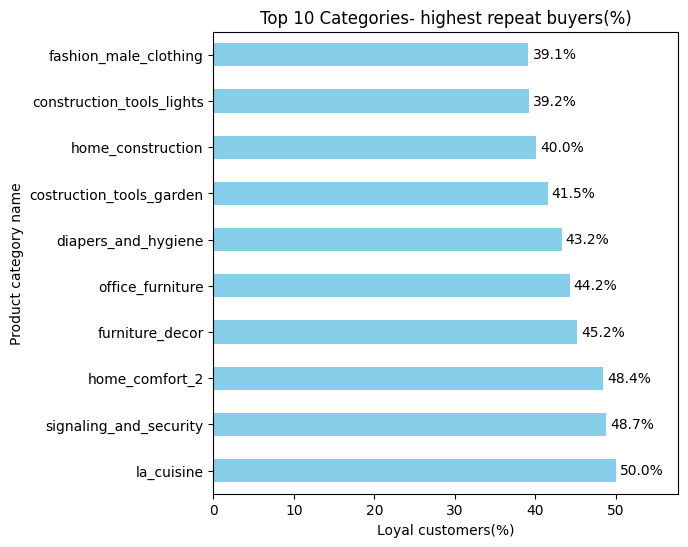

In [100]:
category_repeat_rate= df.groupby('product_category_ename')['is_repeat'].mean() * 100.
ax=category_repeat_rate.nlargest(10).plot(kind='barh', figsize=(6,6), color="skyblue")
for bars in ax.containers:
    ax.bar_label(bars, padding=3, fmt ='%.1f%%')
plt.xlim(0, ax.get_xlim()[1] * 1.10)  
plt.title("Top 10 Categories- highest repeat buyers(%)")
plt.xlabel("Loyal customers(%)")
plt.ylabel("Product category name")

# This line automates the saving
plt.savefig(f'../visuals/16_Top 10 Categories- highest repeat buyers(%)')
plt.show()
    
plt.close() # Important: closes the plot so it doesn't eat up memory

###### Repeat purchase behavior is strongest in home and security-related categories, suggesting these segments drive customer loyalty. Focusing retention strategies on these categories can maximize lifetime value while underperforming categories need experience or pricing interventions.

##### PAYMENT & TRANSACTION BEHAVIOR (Finance View) <br> Business Objective: Optimize payment methods.

##### Which payment type is most commonly used?

In [101]:
cols

,column
0,order_id
1,customer_id
2,order_status
3,order_purchase_timestamp
4,order_approved_at
5,order_delivered_carrier_date
6,order_delivered_customer_date
7,order_estimated_delivery_date
8,payment_sequential
9,payment_type


C:\Users\lenovo\AppData\Local\Temp\ipykernel_8592\2779228859.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=payment, x='payment_type', y='order_id', palette=my_colors)


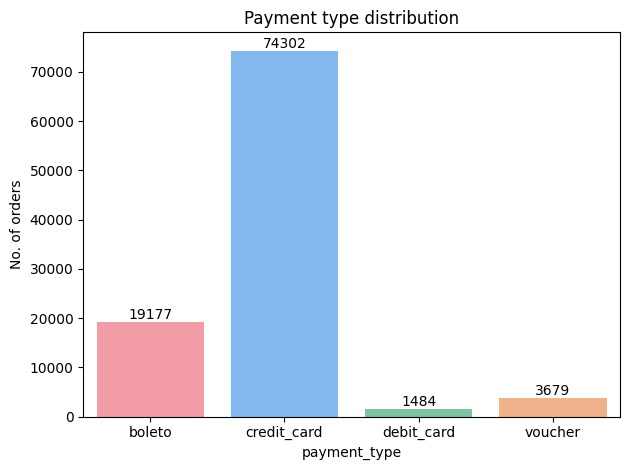

In [102]:
payment=df.groupby('payment_type')['order_id'].nunique().reset_index()
# Define your custom palette
my_colors = ['#FF8E9D', '#70B9FE', '#71D1A1', '#FFB07C']
ax=sns.barplot(data=payment, x='payment_type', y='order_id', palette=my_colors)
for bars in ax.containers:
    ax.bar_label(bars)
plt.title("Payment type distribution")
plt.ylabel("No. of orders")
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/17_Payment type distribution')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

##### Which payment method generates highest revenue?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_8592\1973513215.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=pmt_revenue, x='payment_type', y='price', palette=my_colors)


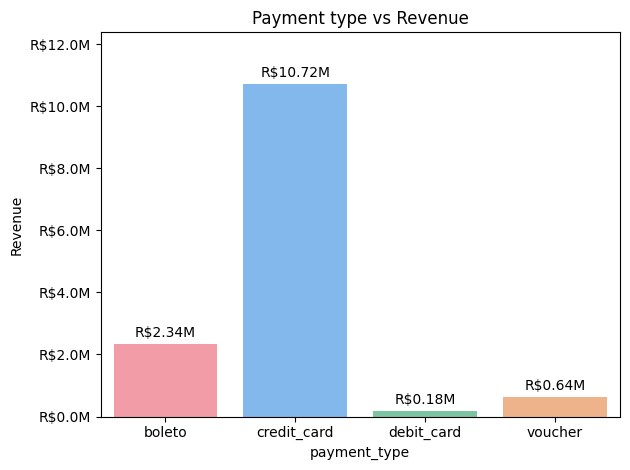

In [103]:
pmt_revenue=df.groupby('payment_type')['price'].sum().reset_index()
# Define your custom palette
my_colors = ['#FF8E9D', '#70B9FE', '#71D1A1', '#FFB07C']
ax=sns.barplot(data=pmt_revenue, x='payment_type', y='price', palette=my_colors)
for bars in ax.containers:
    ax.bar_label(bars, labels=[f"R${v/1e6:.2f}M" for v in bars.datavalues], padding=3)

#  Format the Y-axis tick labels as well
# use a FuncFormatter to divide the raw value by 1,000,000
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"R${x/1e6:.1f}M"))

plt.title("Payment type vs Revenue")
plt.ylabel("Revenue")
plt.ylim(0, ax.get_ylim()[1] * 1.10) 
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/18_Payment type vs Revenue')
plt.show()
    
plt.close() # Important: closes the plot so it doesn't eat up memory

###### Revenue is heavily concentrated in credit card payments, which account for the majority of total sales, making it the platform’s most critical payment method. Boleto contributes a meaningful but much smaller share, while debit card and voucher generate minimal revenue. This suggests that optimizing the credit card checkout experience and offering card-based promotions could yield the highest revenue impact, while alternative payment methods may need incentives or UX improvements to increase adoption.

##### Do installment payments lead to higher order value?

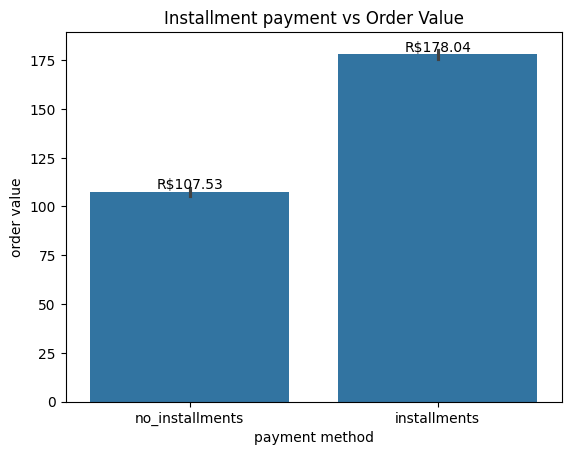

In [104]:
# 1. Order-level revenue
order_rev = df.groupby('order_id')['price'].sum().reset_index(name='order_value')

# 2. Order-level installment flag
order_installments = df.groupby('order_id')['payment_installments'].max().reset_index()
order_installments['is_installments'] = order_installments['payment_installments'] > 1

# 3. Combine
order_df = order_rev.merge(order_installments[['order_id', 'is_installments']], on='order_id')

# 4. Compare AOV
order_df.groupby('is_installments')['order_value'].mean()
ax=sns.barplot(data=order_df, x='is_installments', y='order_value')
for bars in ax.containers:
    ax.bar_label(bars, fmt=f"R$%.2f")
plt.title("Installment payment vs Order Value")
plt.xlabel("payment method")
plt.ylabel("order value")
plt.xticks(ticks=np.arange(0,2), labels=["no_installments","installments"])

# This line automates the saving
plt.savefig(f'../visuals/19_Installment payment vs Order Value')
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### Orders paid using installments have a significantly higher average order value (178.04) compared to single-payment orders (107.53), indicating that installment options enable customers to purchase higher-priced items. This suggests that promoting installment payment options can increase basket size and overall revenue.

##### Are certain payment types linked to more cancellations?

In [105]:
cancel_orders=df.loc[df['order_status'] != 'delivered', ['order_id','order_status','payment_type']]
cancel_orders['order_id'].nunique()

6

In [106]:
df.groupby(['order_status'])['payment_type'].value_counts()

order_status  payment_type
canceled      credit_card         7
delivered     credit_card     85364
              boleto          22490
              voucher          6181
              debit_card       1661
Name: count, dtype: int64

In [107]:
df['order_id'].nunique()

96461

###### There is no clear relationship between payment method and order cancellations. Only 6 out of 96,461 orders were canceled, and all of them were paid via credit card; however, this is likely due to credit cards being the dominant payment method overall. The extremely low cancellation volume indicates that payment type is not a meaningful driver of order cancellation in this dataset.

##### Does payment method affect delivery speed?

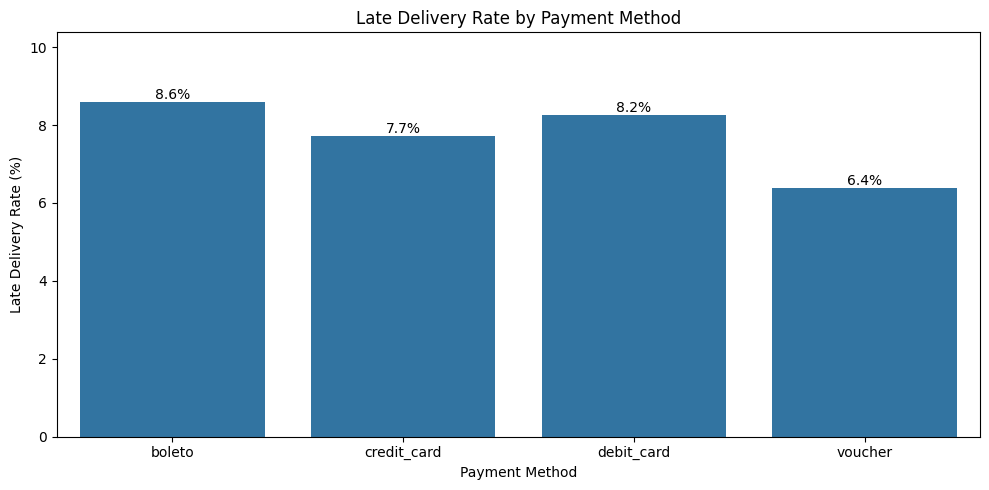

In [108]:
payment_delay = (
    df.groupby('payment_type')['is_late']
      .mean()
      .reset_index(name='late_rate')
)
payment_delay['late_rate_pct'] = payment_delay['late_rate'] * 100
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=payment_delay,
    x='payment_type',
    y='late_rate_pct'
)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%")
plt.title("Late Delivery Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Late Delivery Rate (%)")
plt.ylim(0, ax.get_ylim()[1]* 1.15)
plt.xticks(rotation=0)
plt.tight_layout()
# This line automates the saving
plt.savefig(f'../visuals/20_Late Delivery Rate by Payment Method')
    
plt.show()

plt.close() # Important: closes the plot so it doesn't eat up memory

###### “The bar chart shows clear variation in late delivery rates across payment methods.Boleto and voucher payments exhibit higher late delivery percentages compared to card-based payments, indicating that payment method is associated with delivery delays.”

In [109]:
df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,...,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,order_month,delivery_days,is_late,is_repeat
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,...,9350,maua,SP,3149.0,-23.576983,-46.587161,2017-10,8,False,True
